In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load benchmark results
df = pd.read_csv("sort_result.txt")

bubble = df[df['Algorithm'] == 'BubbleSort']
merge  = df[df['Algorithm'] == 'MergeSort']

print("Sorting Benchmark Results:")
print(df.to_string(index=False))

Sorting Benchmark Results:
    N  Algorithm  Seq_Time  Par_Time  Speedup  Efficiency
  100 BubbleSort  0.000050  0.091129 0.000551    0.000034
  100  MergeSort  0.000025  0.000076 0.323927    0.020245
 1000 BubbleSort  0.004949  0.014574 0.339551    0.021222
 1000  MergeSort  0.000284  0.000318 0.894726    0.055920
10000 BubbleSort  0.424359  0.231604 1.832261    0.114516
10000  MergeSort  0.004171  0.001507 2.766744    0.172921
20000 BubbleSort  1.952865  0.422700 4.619981    0.288749
20000  MergeSort  0.008216  0.011515 0.713512    0.044595
30000 BubbleSort  4.532311  1.158956 3.910684    0.244418
30000  MergeSort  0.011347  0.008424 1.346977    0.084186


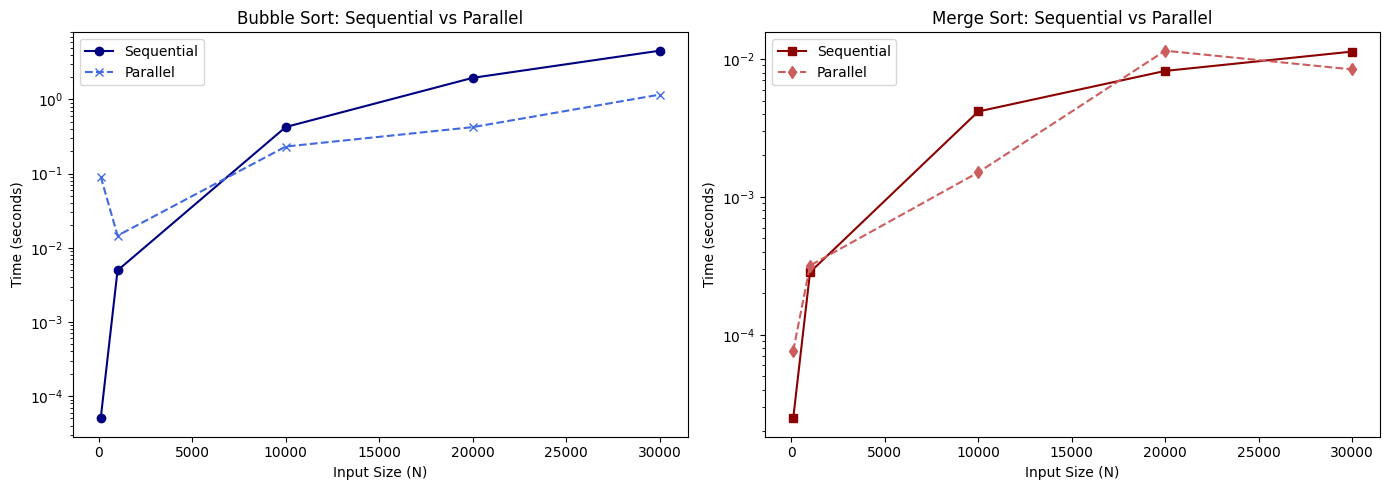

In [2]:
# 1. Sequential vs Parallel Execution Time
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bubble Sort
axes[0].plot(bubble['N'], bubble['Seq_Time'], 'o-', label='Sequential', color='navy')
axes[0].plot(bubble['N'], bubble['Par_Time'], 'x--', label='Parallel', color='royalblue')
# axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Input Size (N)')
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title('Bubble Sort: Sequential vs Parallel')
axes[0].legend()

# Merge Sort
axes[1].plot(merge['N'], merge['Seq_Time'], 's-', label='Sequential', color='darkred')
axes[1].plot(merge['N'], merge['Par_Time'], 'd--', label='Parallel', color='indianred')
# axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Input Size (N)')
axes[1].set_ylabel('Time (seconds)')
axes[1].set_title('Merge Sort: Sequential vs Parallel')
axes[1].legend()

plt.tight_layout()
plt.show()

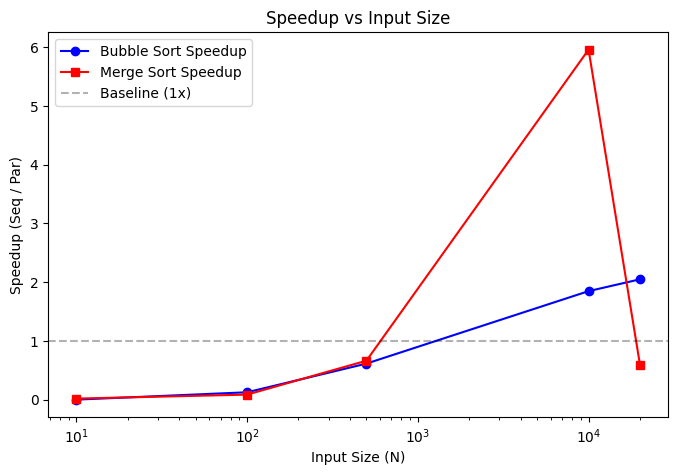

In [3]:
# 2. Speedup Comparison
plt.figure(figsize=(8, 5))
plt.plot(bubble['N'], bubble['Speedup'], 'o-', label='Bubble Sort Speedup', color='blue')
plt.plot(merge['N'],  merge['Speedup'],  's-', label='Merge Sort Speedup',  color='red')
plt.axhline(y=1, color='black', linestyle='--', alpha=0.3, label='Baseline (1x)')
plt.xscale('log')
plt.xlabel('Input Size (N)')
plt.ylabel('Speedup (Seq / Par)')
plt.title('Speedup vs Input Size')
plt.legend()
plt.show()

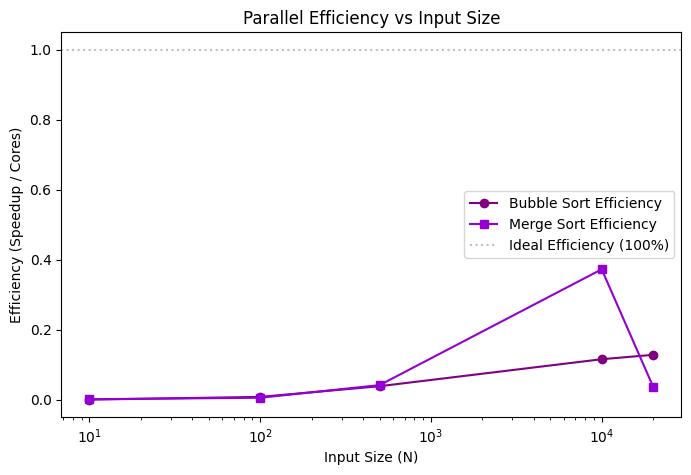

In [4]:
# 3. Efficiency Comparison
plt.figure(figsize=(8, 5))
plt.plot(bubble['N'], bubble['Efficiency'], 'o-', label='Bubble Sort Efficiency', color='purple')
plt.plot(merge['N'],  merge['Efficiency'],  's-', label='Merge Sort Efficiency',  color='darkviolet')
plt.axhline(y=1, color='grey', linestyle=':', alpha=0.5, label='Ideal Efficiency (100%)')
plt.xscale('log')
plt.xlabel('Input Size (N)')
plt.ylabel('Efficiency (Speedup / Cores)')
plt.title('Parallel Efficiency vs Input Size')
plt.legend()
plt.show()